# Australian Crime Dashboard
## Notebook 1 – Data Exploration

This notebook explores the cleaned Australian Bureau of Statistics (ABS) offender dataset after extraction, cleaning, validation, and reshaping.

Objectives:

- Verify the cleaned dataset
- Explore trends across financial years
- Identify major offence categories
- Generate insights for the interactive dashboard

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "../data/processed/offenders_clean.csv"
)

df.head()

,Offence_Category,Year,Offender_Count,Offender_Rate
0,01 Homicide and related offences(e),2008–09,816.0,4.4
1,011 Murder,2008–09,318.0,1.7
2,012 Attempted Murder,2008–09,232.0,1.2
3,013 Manslaughter and driving causing death,2008–09,260.0,1.4
4,02 Acts intended to cause injury(f),2008–09,72069.0,384.9


## 1. Dataset Overview

Before analysing the data, inspect its overall structure to ensure the ETL pipeline produced the expected output.

In [3]:
df.shape

(629, 4)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Offence_Category  629 non-null    str    
 1   Year              629 non-null    str    
 2   Offender_Count    629 non-null    float64
 3   Offender_Rate     629 non-null    float64
dtypes: float64(2), str(2)
memory usage: 43.9 KB


In [5]:
df.describe()

,Offender_Count,Offender_Rate
count,629.000000,629.000000
mean,17423.529412,82.661367
std,21937.457448,104.713145
min,85.000000,0.400000
25%,3350.000000,14.900000
50%,8417.000000,39.000000
75%,22190.000000,110.700000
max,98530.000000,405.900000


## 2. Missing Values

Confirm that no missing values remain after cleaning.

In [6]:
df.isna().sum()

Offence_Category    0
Year                0
Offender_Count      0
Offender_Rate       0
dtype: int64

## 3. Financial Years

Verify that every financial year has been retained.

In [7]:
df["Year"].unique()

<ArrowStringArray>
['2008–09', '2009–10', '2010–11', '2011–12', '2012–13', '2013–14', '2014–15',
 '2015–16', '2016–17', '2017–18', '2018–19', '2019–20', '2020–21', '2021–22',
 '2022–23', '2023–24', '2024–25']
Length: 17, dtype: str

In [8]:
df["Year"].nunique()

17

## 4. Offence Categories

Inspect the offence categories included in the dataset.

In [9]:
df["Offence_Category"].unique()

<ArrowStringArray>
[           '01 Homicide and related offences(e)',
                                     '011 Murder',
                           '012 Attempted Murder',
     '013 Manslaughter and driving causing death',
           '02 Acts intended to cause injury(f) ',
                                    '021 Assault',
        '029 Other acts intended to cause injury',
      '03 Sexual assault and related offences(g)',
                             '031 Sexual assault',
             '032 Non–assaultive sexual offences',
                 '04 Dangerous/negligent acts(h)',
                        '05 Abduction/harassment',
                           '06 Robbery/extortion',
                  '07 Unlawful entry with intent',
                                 '08 Theft(i)(j)',
                        '081 Motor vehicle theft',
              '082 Theft (except motor vehicles)',
        '083 Receive or handle proceeds of crime',
                          '09 Fraud/deception(k)',
            

In [10]:
df["Offence_Category"].nunique()

37

## 5. Total Offenders by Financial Year

Calculate the total number of offenders recorded each financial year.

In [11]:
yearly_totals = (
    df.groupby("Year")["Offender_Count"]
      .sum()
      .reset_index()
)

yearly_totals

,Year,Offender_Count
0,2008–09,655770.0
1,2009–10,689419.0
2,2010–11,680066.0
3,2011–12,668513.0
4,2012–13,696041.0
5,2013–14,689631.0
6,2014–15,678061.0
7,2015–16,681631.0
8,2016–17,672010.0
9,2017–18,669063.0


## 6. Major Offence Divisions

The ABS dataset contains both major offence divisions and detailed subcategories.

Filter the major divisions only.

In [12]:
major = df[
    df["Offence_Category"]
    .str.match(r"^\d{2}\s")
]

major.head()

,Offence_Category,Year,Offender_Count,Offender_Rate
0,01 Homicide and related offences(e),2008–09,816.0,4.4
4,02 Acts intended to cause injury(f),2008–09,72069.0,384.9
7,03 Sexual assault and related offences(g),2008–09,6340.0,33.9
10,04 Dangerous/negligent acts(h),2008–09,1680.0,9.0
11,05 Abduction/harassment,2008–09,3598.0,19.2


## 7. Major Division Totals

Calculate yearly totals for the major offence divisions.

In [13]:
major.groupby("Year")["Offender_Count"]\
     .sum()\
     .reset_index()

,Year,Offender_Count
0,2008–09,369725.0
1,2009–10,387195.0
2,2010–11,382764.0
3,2011–12,376905.0
4,2012–13,393486.0
5,2013–14,387333.0
6,2014–15,381790.0
7,2015–16,383318.0
8,2016–17,376240.0
9,2017–18,375282.0


## 8. Largest Offence Categories (2024–25)

Identify which offence divisions recorded the highest offender counts in the most recent year.

In [14]:
latest = (
    major[major["Year"] == "2024–25"]
    .sort_values(
        "Offender_Count",
        ascending=False
    )
)

latest[[
    "Offence_Category",
    "Offender_Count"
]]

,Offence_Category,Offender_Count
596,02 Acts intended to cause injury(f),98530.0
615,10 Illicit drug offences(l),47550.0
606,08 Theft(i)(j),35266.0
625,15 Offences against justice(n)(o),32081.0
621,13 Public order offences(m),30952.0
619,11 Weapons/explosives,16769.0
620,12 Property damage and environmental pollution,13714.0
605,07 Unlawful entry with intent,10404.0
599,03 Sexual assault and related offences(g),10052.0
610,09 Fraud/deception(k),7912.0


## 9. Key Findings

- The cleaned dataset contains 629 observations across 17 financial years.
- No missing values remain after cleaning.
- Fifteen major offence divisions are represented, along with detailed offence subcategories.
- Total offender numbers increased until approximately 2015–16 before declining.
- Acts intended to cause injury consistently records the highest number of offenders.
- Homicide offences represent the smallest major offence division.
- The dataset is ready for dashboard visualisation.

## 10. Data Visualisation


### 10.1. Total Offenders Over Time

This visual shows the change in total recorded offenders across the available financial years.

This provides a high-level overview of offender trends before analysing individual offence categories.

In [15]:
yearly_totals = (
    df.groupby("Year")["Offender_Count"]
    .sum()
    .reset_index()
)

yearly_totals

,Year,Offender_Count
0,2008–09,655770.0
1,2009–10,689419.0
2,2010–11,680066.0
3,2011–12,668513.0
4,2012–13,696041.0
5,2013–14,689631.0
6,2014–15,678061.0
7,2015–16,681631.0
8,2016–17,672010.0
9,2017–18,669063.0


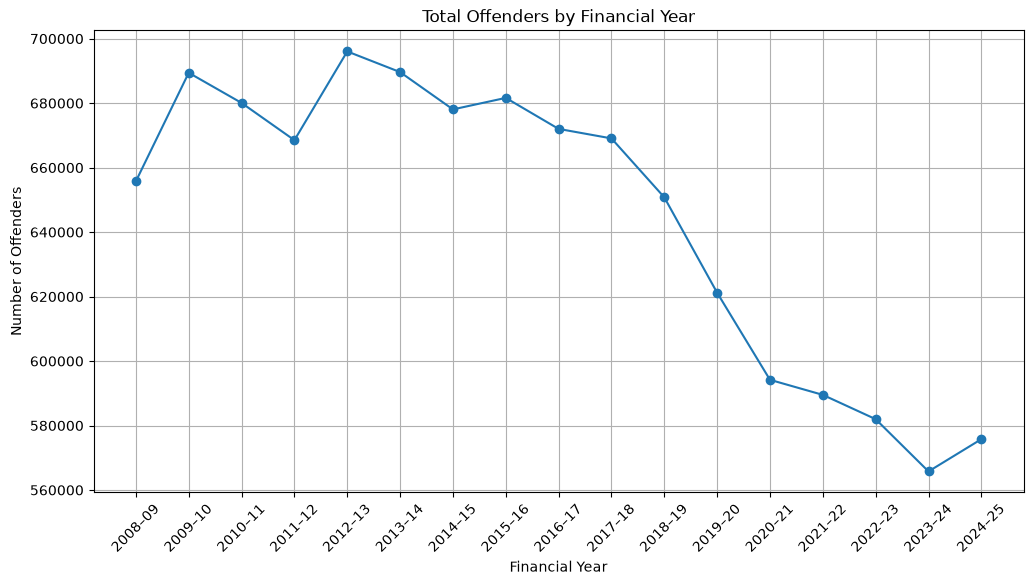

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    yearly_totals["Year"],
    yearly_totals["Offender_Count"],
    marker="o"
)

plt.title(
    "Total Offenders by Financial Year"
)

plt.xlabel(
    "Financial Year"
)

plt.ylabel(
    "Number of Offenders"
)

plt.xticks(
    rotation=45
)

plt.grid(
    True
)

plt.show()

### Observation

The number of recorded offenders increased during the early part of the dataset, reaching a peak around 2015–16.

Following this peak, offender numbers generally declined, with the lowest values occurring in recent years.

A small increase is visible in 2024–25 compared with the previous year, although counts remain below historical highs.

### 10.2. Largest Offence Categories in 2024–25

This analysis identifies the major offence divisions with the highest offender counts in the latest reporting period.

In [17]:
latest = (
    major[
        major["Year"] == "2024–25"
    ]
    .sort_values(
        "Offender_Count",
        ascending=False
    )
)

latest

,Offence_Category,Year,Offender_Count,Offender_Rate
596,02 Acts intended to cause injury(f),2024–25,98530.0,405.9
615,10 Illicit drug offences(l),2024–25,47550.0,195.9
606,08 Theft(i)(j),2024–25,35266.0,145.3
625,15 Offences against justice(n)(o),2024–25,32081.0,132.2
621,13 Public order offences(m),2024–25,30952.0,127.5
619,11 Weapons/explosives,2024–25,16769.0,69.1
620,12 Property damage and environmental pollution,2024–25,13714.0,56.5
605,07 Unlawful entry with intent,2024–25,10404.0,42.9
599,03 Sexual assault and related offences(g),2024–25,10052.0,41.4
610,09 Fraud/deception(k),2024–25,7912.0,32.6


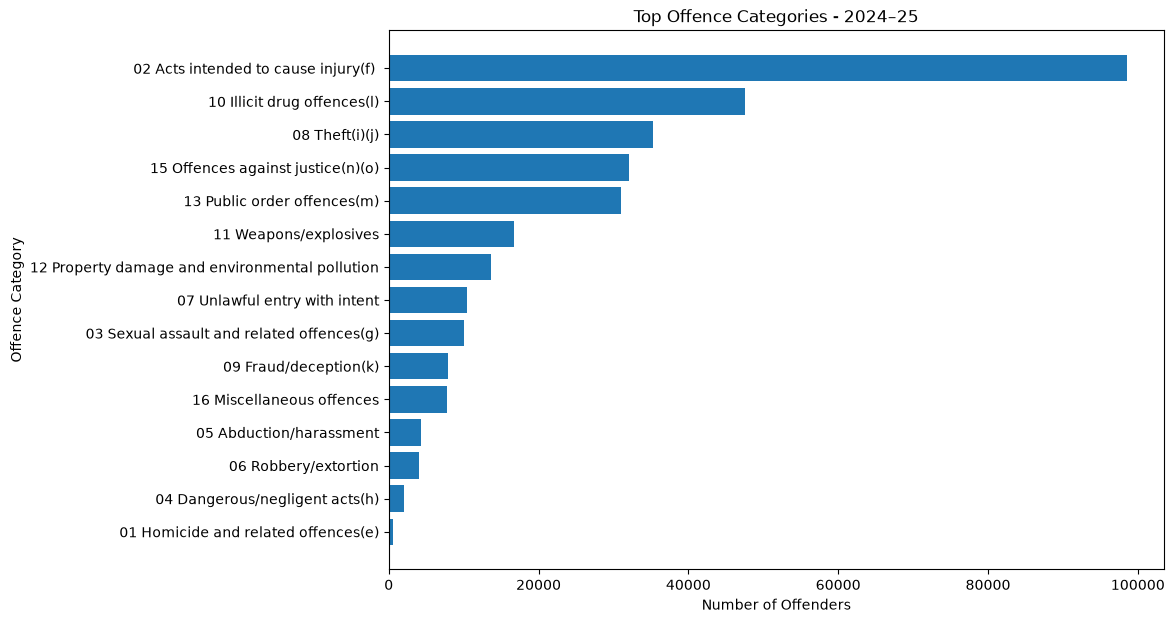

In [18]:
plt.figure(figsize=(10,7))

plt.barh(
    latest["Offence_Category"],
    latest["Offender_Count"]
)

plt.title(
    "Top Offence Categories - 2024–25"
)

plt.xlabel(
    "Number of Offenders"
)

plt.ylabel(
    "Offence Category"
)

plt.gca().invert_yaxis()

plt.show()

### Observation

Acts intended to cause injury represents the largest offence division in 2024–25, followed by illicit drug offences and theft-related offences.

Homicide and related offences represent the smallest major offence division by offender count.

The distribution shows that a small number of offence divisions contribute a large proportion of recorded offenders.

### 10.3. Major Offence Division Trends

This visual compares trends across major offence divisions to identify changes in offence patterns over time.

In [19]:
major_trends = (
    major
    .groupby(
        [
            "Year",
            "Offence_Category"
        ]
    )
    ["Offender_Count"]
    .sum()
    .reset_index()
)

major_trends.head()

,Year,Offence_Category,Offender_Count
0,2008–09,01 Homicide and related offences(e),816.0
1,2008–09,02 Acts intended to cause injury(f),72069.0
2,2008–09,03 Sexual assault and related offences(g),6340.0
3,2008–09,04 Dangerous/negligent acts(h),1680.0
4,2008–09,05 Abduction/harassment,3598.0


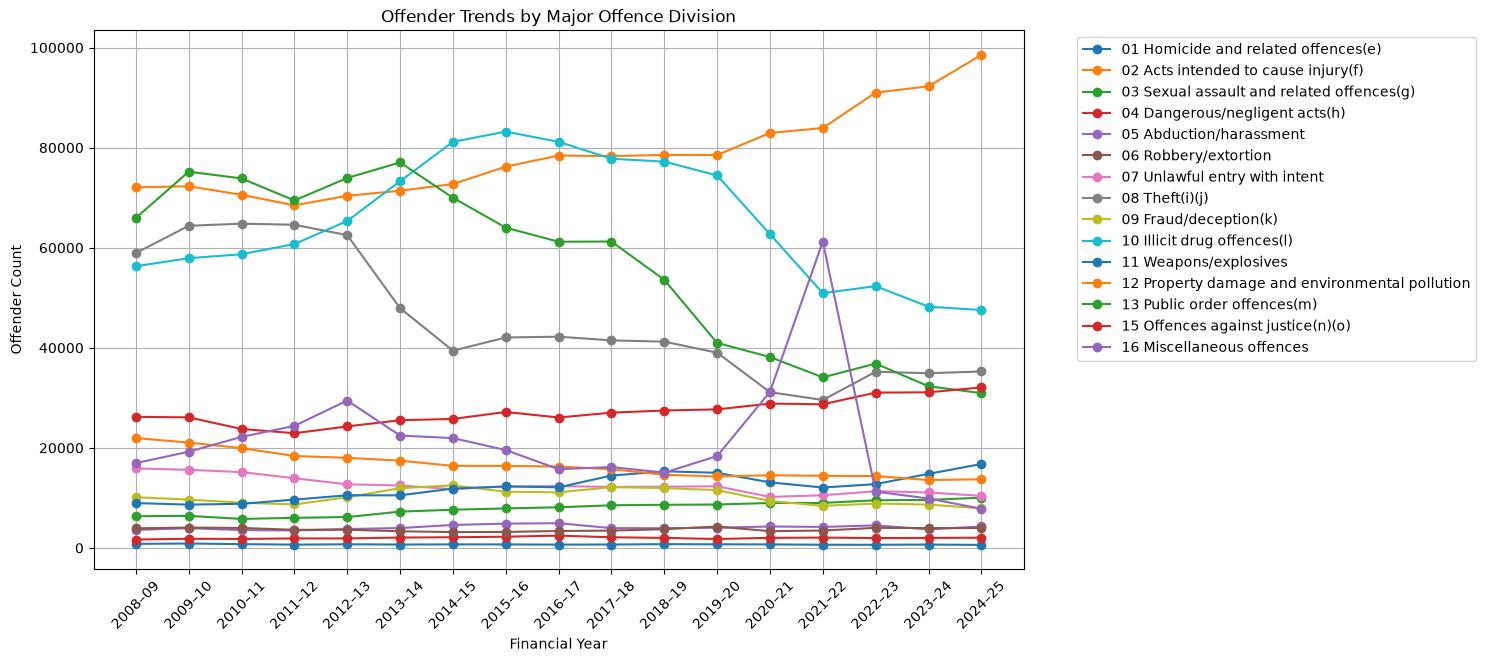

In [20]:
plt.figure(figsize=(12,7))

for offence in major_trends["Offence_Category"].unique():

    subset = major_trends[
        major_trends["Offence_Category"] == offence
    ]

    plt.plot(
        subset["Year"],
        subset["Offender_Count"],
        marker="o",
        label=offence
    )


plt.title(
    "Offender Trends by Major Offence Division"
)

plt.xlabel(
    "Financial Year"
)

plt.ylabel(
    "Offender Count"
)

plt.xticks(
    rotation=45
)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(True)

plt.show()

# 11. Notebook Summary

This notebook completed exploratory analysis of the cleaned ABS offender dataset.

Key outcomes:

- Confirmed the dataset contains 17 financial years of data.
- Verified there are no missing values after ETL processing.
- Identified 15 major offence divisions.
- Observed an overall decline in offender counts after the mid-2010s.
- Identified acts intended to cause injury as the largest offence division.
- Prepared analytical foundations for dashboard development.

The dataset is now ready for deeper analysis and interactive dashboard creation.